# 1 - Install

In [1]:
!pip -q install kaggle pandas scikit-learn tqdm matplotlib pillow torchvision

# 2 - Imports

In [2]:
import os, json, zipfile, math, random, time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from torch import amp
from tqdm import tqdm
import matplotlib.pyplot as plt
from contextlib import nullcontext

# 3 - Config and Reproducibility

In [ ]:
SEED = 42

def set_seed(seed=42, deterministic=True):
    # Fix randomness for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic runs are reproducible
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

WORKDIR = os.path.abspath("./statefarm_vit_project")
DATA_DIR = os.path.join(WORKDIR, "data")
EXTRACT_DIR = os.path.join(DATA_DIR, "extracted")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("WORKDIR:", WORKDIR)
print("DATA_DIR:", DATA_DIR)
print("EXTRACT_DIR:", EXTRACT_DIR)

Device: cuda
WORKDIR: /home/aibox/statefarm_vit_project
DATA_DIR: /home/aibox/statefarm_vit_project/data
EXTRACT_DIR: /home/aibox/statefarm_vit_project/data/extracted


# 4 - AMP Autocast Compatibility (AUTOCAST)

In [ ]:
def get_autocast_context(device: str):
    if device == "cuda":
        try:
            return amp.autocast(device_type="cuda", enabled=True)
        except TypeError:
            return amp.autocast(enabled=True)
    else:
        return nullcontext()

AUTOCAST = get_autocast_context(DEVICE)
print("✅ AUTOCAST context ready for:", DEVICE)

✅ AUTOCAST context ready for: cuda


# 5 - Kaggle Credentials

In [5]:
# Configure Kaggle credentials (token-based or legacy)
kaggle_dir = os.path.join(os.path.expanduser("~"), ".kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

access_token_path = os.path.join(kaggle_dir, "access_token")
legacy_json_path = os.path.join(kaggle_dir, "kaggle.json")

api_token = os.environ.get("KAGGLE_API_TOKEN", "").strip()
legacy_user = os.environ.get("KAGGLE_USERNAME", "").strip()
legacy_key  = os.environ.get("KAGGLE_KEY", "").strip()

method = "No credentials found"

if api_token:
    with open(access_token_path, "w") as f:
        f.write(api_token)
    method = "KAGGLE_API_TOKEN"
elif legacy_user and legacy_key:
    with open(legacy_json_path, "w") as f:
        json.dump({"username": legacy_user, "key": legacy_key}, f)
    method = "KAGGLE_USERNAME/KAGGLE_KEY"
elif os.path.isfile(access_token_path):
    method = "Existing access_token"
elif os.path.isfile(legacy_json_path):
    method = "Existing kaggle.json"

# Secure permissions
for p in [access_token_path, legacy_json_path]:
    if os.path.isfile(p):
        try:
            os.chmod(p, 0o600)
        except Exception:
            pass

print("Auth method:", method)
print("access_token exists:", os.path.isfile(access_token_path))
print("kaggle.json exists:", os.path.isfile(legacy_json_path))

Auth method: Existing access_token
access_token exists: True
kaggle.json exists: False


# 6 - Download Dataset

In [6]:
# Download Kaggle competition data if not already present
zip_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".zip")]

if len(zip_files) == 0:
    !kaggle competitions download -c state-farm-distracted-driver-detection -p "{DATA_DIR}"
    zip_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".zip")]

print("ZIP files:", zip_files)
assert len(zip_files) > 0, "Dataset zip file not found."

ZIP files: ['state-farm-distracted-driver-detection.zip']


# 7 - Extract Dataset

In [7]:
marker = os.path.join(EXTRACT_DIR, "_extracted.ok")

if not os.path.isfile(marker):
    for z in zip_files:
        zpath = os.path.join(DATA_DIR, z)
        with zipfile.ZipFile(zpath, "r") as zr:
            zr.extractall(EXTRACT_DIR)
    with open(marker, "w") as f:
        f.write("ok")

print("Extraction ready:", os.path.isfile(marker))

Extraction ready: True


# 8 - Locate Paths

In [8]:
def find_file(root, filename):
    for d, _, files in os.walk(root):
        if filename in files:
            return os.path.join(d, filename)
    return None

def find_dir(root, dirname):
    for d, dirs, _ in os.walk(root):
        if dirname in dirs:
            return os.path.join(d, dirname)
    return None

CSV_PATH = find_file(EXTRACT_DIR, "driver_imgs_list.csv")
IMGS_DIR = find_dir(EXTRACT_DIR, "imgs")

print("CSV_PATH:", CSV_PATH)
print("IMGS_DIR:", IMGS_DIR)

assert CSV_PATH is not None, "driver_imgs_list.csv not found."
assert IMGS_DIR is not None, "imgs directory not found."

TRAIN_DIR = os.path.join(IMGS_DIR, "train")
assert os.path.isdir(TRAIN_DIR), "imgs/train directory not found."

CSV_PATH: /home/aibox/statefarm_vit_project/data/extracted/driver_imgs_list.csv
IMGS_DIR: /home/aibox/statefarm_vit_project/data/extracted/imgs


# 9 - Build DataFrame

In [10]:
# Read CSV mapping each image to its class and driver(subject)
df = pd.read_csv(CSV_PATH)

# Build full file paths for each image
df["filepath"] = df.apply(lambda r: os.path.join(TRAIN_DIR, r["classname"], r["img"]), axis=1)

# Safety: keep only existing files
df = df[df["filepath"].apply(os.path.isfile)].reset_index(drop=True)

# Build class index maps
class_names = sorted(df["classname"].unique())
class_to_id = {c: i for i, c in enumerate(class_names)}
id_to_class = {i: c for c, i in class_to_id.items()}
NUM_CLASSES = len(class_names)

print("Samples:", len(df))
print("Drivers:", df["subject"].nunique())
print("NUM_CLASSES:", NUM_CLASSES)
print("Class names:", class_names)

df.head()

Samples: 22424
Drivers: 26
NUM_CLASSES: 10
Class names: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']


,subject,classname,img,filepath
0,p002,c0,img_44733.jpg,/home/aibox/statefarm_vit_project/data/extract...
1,p002,c0,img_72999.jpg,/home/aibox/statefarm_vit_project/data/extract...
2,p002,c0,img_25094.jpg,/home/aibox/statefarm_vit_project/data/extract...
3,p002,c0,img_69092.jpg,/home/aibox/statefarm_vit_project/data/extract...
4,p002,c0,img_92629.jpg,/home/aibox/statefarm_vit_project/data/extract...


# 10 - Driver-Based Split (Leakage-Free)

In [11]:
# Split by driver ID to avoid subject leakage across sets
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(df, groups=df["subject"]))

df_trainval = df.iloc[trainval_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss2.split(df_trainval, groups=df_trainval["subject"]))

df_train = df_trainval.iloc[train_idx].reset_index(drop=True)
df_val = df_trainval.iloc[val_idx].reset_index(drop=True)

print("Train:", len(df_train), "| Val:", len(df_val), "| Test:", len(df_test))
print("Driver overlap train/test:", len(set(df_train.subject) & set(df_test.subject)))

Train: 15538 | Val: 3361 | Test: 3525
Driver overlap train/test: 0


# Q4 - Vision Transformer From Scratch + Train With AdamW and SGD
# 11 - Transforms (Train vs Eval)

In [12]:
IMG_SIZE = 224
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

# Data augmentation used during training
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Deterministic preprocessing for validation and test
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# 12 - Dataset and DataLoaders (WITH WeightedRandomSampler)

In [13]:
from torch.utils.data import WeightedRandomSampler

class DriverDataset(Dataset):
    def __init__(self, df, transform, class_to_id):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.class_to_id = class_to_id

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img = Image.open(r["filepath"]).convert("RGB")
        x = self.transform(img)
        y = self.class_to_id[r["classname"]]
        return x, y, r["filepath"]

BATCH_SIZE = 64
NUM_WORKERS = 4
PIN_MEMORY = (DEVICE == "cuda")

def worker_init_fn(worker_id):
    s = SEED + worker_id
    np.random.seed(s)
    random.seed(s)

train_ds = DriverDataset(df_train, train_tfms, class_to_id)
val_ds   = DriverDataset(df_val,   eval_tfms,  class_to_id)
test_ds  = DriverDataset(df_test,  eval_tfms,  class_to_id)

# Compute class-balanced sampling weights
train_labels = df_train["classname"].map(class_to_id).values
counts = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights = 1.0 / np.maximum(counts, 1)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
    worker_init_fn=worker_init_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=worker_init_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=worker_init_fn
)

xb, yb, _ = next(iter(train_loader))
print("train_loader batch:", xb.shape, yb.shape)

train_loader batch: torch.Size([64, 3, 224, 224]) torch.Size([64])


# 13 - Q4: Model Definitions (ViT From Scratch)

In [14]:
# Defining all ViT classes here guarantees VisionTransformer is available for training

class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=384):
        super().__init__()
        assert img_size % patch_size == 0
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden)
        self.fc2 = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class EncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4.0, drop=0.1, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=attn_drop, batch_first=True)
        self.drop1 = nn.Dropout(drop)

        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, mlp_ratio=mlp_ratio, drop=drop)

    def forward(self, x):
        x1 = self.norm1(x)
        a, _ = self.attn(x1, x1, x1, need_weights=False)
        x = x + self.drop1(a)
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 num_classes=10, embed_dim=384, depth=6, heads=6,
                 mlp_ratio=4.0, drop=0.1, attn_drop=0.0):
        super().__init__()

        self.patch = PatchEmbed(img_size, patch_size, in_chans, embed_dim)

        grid = img_size // patch_size
        num_patches = grid * grid

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + num_patches, embed_dim))
        self.pos_drop = nn.Dropout(drop)

        self.blocks = nn.ModuleList([
            EncoderBlock(embed_dim, heads, mlp_ratio, drop, attn_drop)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)

    def forward(self, x):
        x = self.patch(x)
        B, N, D = x.shape

        cls = self.cls_token.expand(B, 1, D)
        x = torch.cat([cls, x], dim=1)
        x = self.pos_drop(x + self.pos_embed[:, :1 + N, :])

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        return self.head(x[:, 0])

print("✅ VisionTransformer is defined and ready.")

✅ VisionTransformer is defined and ready.


# 14 - Q4: Scheduler

In [15]:
def build_warmup_cosine_scheduler(optimizer, warmup_steps, total_steps):
    # Linear warmup then cosine decay
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# 15 - Q4: Train/Evaluate Utilities + EarlyStopping

In [16]:
def evaluate(model, loader, criterion):
    # Evaluate model on validation/test (no grads)
    model.eval()
    loss_sum = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for x, y, _ in tqdm(loader, leave=True):
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            # Mixed precision context (safe across torch versions)
            with AUTOCAST:
                logits = model(x)
                loss = criterion(logits, y)

            loss_sum += float(loss.item()) * x.size(0)
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            targets.extend(y.detach().cpu().numpy())

    avg_loss = loss_sum / len(loader.dataset)
    acc = accuracy_score(targets, preds)
    f1m = f1_score(targets, preds, average="macro")
    return avg_loss, acc, f1m


def train_one_epoch(model, loader, optimizer, scaler, scheduler=None, grad_clip=1.0, criterion=None):
    # Train for one epoch
    model.train()
    loss_sum = 0.0
    preds, targets = [], []

    for x, y, _ in tqdm(loader, leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Forward pass under autocast
        with AUTOCAST:
            logits = model(x)
            loss = criterion(logits, y)

        # Backward + optimizer step (scaler is enabled only on CUDA)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()

        # Scheduler step per iteration
        if scheduler is not None:
            scheduler.step()

        loss_sum += float(loss.item()) * x.size(0)
        preds.extend(logits.argmax(1).detach().cpu().numpy())
        targets.extend(y.detach().cpu().numpy())

    avg_loss = loss_sum / len(loader.dataset)
    acc = accuracy_score(targets, preds)
    f1m = f1_score(targets, preds, average="macro")
    return avg_loss, acc, f1m


class EarlyStopping:
    # Early stopping by validation accuracy
    def __init__(self, patience=5, mode="max", min_delta=1e-6):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.bad_epochs = 0

    def step(self, score, model):
        improved = False
        if self.best_score is None:
            improved = True
        else:
            if self.mode == "max":
                improved = (score - self.best_score) > self.min_delta
            else:
                improved = (self.best_score - score) > self.min_delta

        if improved:
            self.best_score = score
            self.best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1

        return improved

    def should_stop(self):
        return self.bad_epochs >= self.patience


def fit(model, train_loader, val_loader, optimizer, scheduler, epochs, patience, criterion, save_path):
    # Full training loop with early stopping + checkpoint saving
    history = []
    earlystop = EarlyStopping(patience=patience, mode="max")

    # GradScaler should be enabled only on CUDA
    scaler = amp.GradScaler(enabled=(DEVICE == "cuda"))

    best_val_acc = -1.0
    best_state = None

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1 = train_one_epoch(
            model, train_loader, optimizer, scaler=scaler, scheduler=scheduler, grad_clip=1.0, criterion=criterion
        )
        va_loss, va_acc, va_f1 = evaluate(model, val_loader, criterion)

        history.append({
            "epoch": ep,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "train_f1": tr_f1,
            "val_loss": va_loss,
            "val_acc": va_acc,
            "val_f1": va_f1
        })

        print(
            f"Epoch {ep:02d} | "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f} f1 {tr_f1:.4f} | "
            f"val loss {va_loss:.4f} acc {va_acc:.4f} f1 {va_f1:.4f}"
        )

        if earlystop.step(va_acc, model):
            best_val_acc = va_acc
            best_state = earlystop.best_state
            torch.save(
                {"model_state_dict": best_state, "val_acc": best_val_acc, "epoch": ep},
                save_path
            )

        if earlystop.should_stop():
            print("Early stopping triggered.")
            break

    return history, best_state, best_val_acc

# 16 - Q4: Train AdamW vs SGD + Select Best

In [17]:
assert "VisionTransformer" in globals(), "VisionTransformer is not defined."

MODEL_CFG = {
    "img_size": IMG_SIZE,
    "patch_size": 16,
    "in_chans": 3,
    "num_classes": NUM_CLASSES,
    "embed_dim": 384,
    "depth": 6,
    "heads": 6,
    "mlp_ratio": 4.0,
    "drop": 0.1,
    "attn_drop": 0.0,
}

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

EPOCHS = 35
PATIENCE = 10

total_steps = EPOCHS * len(train_loader)
warmup_steps = int(0.1 * total_steps)

# AdamW optimizer
set_seed(SEED, deterministic=True)
model_adamw = VisionTransformer(**MODEL_CFG).to(DEVICE)
opt_adamw = torch.optim.AdamW(
    model_adamw.parameters(),
    lr=3e-4,
    weight_decay=0.05
)
sch_adamw = build_warmup_cosine_scheduler(
    opt_adamw,
    warmup_steps,
    total_steps
)

adamw_ckpt = os.path.join(WORKDIR, "best_model_adamw.pt")
print("\nQ4 Run: AdamW")
hist_adamw, best_state_adamw, best_val_adamw = fit(
    model_adamw,
    train_loader,
    val_loader,
    opt_adamw,
    sch_adamw,
    epochs=EPOCHS,
    patience=PATIENCE,
    criterion=criterion,
    save_path=adamw_ckpt
)

# SGD optimizer
set_seed(SEED, deterministic=True)
model_sgd = VisionTransformer(**MODEL_CFG).to(DEVICE)
opt_sgd = torch.optim.SGD(
    model_sgd.parameters(),
    lr=0.03,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True
)
sch_sgd = build_warmup_cosine_scheduler(
    opt_sgd,
    warmup_steps,
    total_steps
)

sgd_ckpt = os.path.join(WORKDIR, "best_model_sgd.pt")
print("\nQ4 Run: SGD")
hist_sgd, best_state_sgd, best_val_sgd = fit(
    model_sgd,
    train_loader,
    val_loader,
    opt_sgd,
    sch_sgd,
    epochs=EPOCHS,
    patience=PATIENCE,
    criterion=criterion,
    save_path=sgd_ckpt
)

print("\nBest val acc AdamW:", best_val_adamw)
print("Best val acc SGD:", best_val_sgd)

use_adamw = best_val_adamw >= best_val_sgd
selected_name = "AdamW" if use_adamw else "SGD"
selected_val = best_val_adamw if use_adamw else best_val_sgd

print("Selected optimizer:", selected_name)
print("Selected best val acc:", selected_val)


Q4 Run: AdamW


100%|██████████| 53/53 [00:17<00:00,  3.03it/s]  


Epoch 01 | train loss 2.3028 acc 0.1245 f1 0.1208 | val loss 2.4648 acc 0.1360 f1 0.0744


100%|██████████| 53/53 [00:07<00:00,  7.46it/s]  


Epoch 02 | train loss 2.1474 acc 0.2026 f1 0.1869 | val loss 2.4484 acc 0.1544 f1 0.0759


...

Epoch 33 | train loss 0.7499 acc 0.9037 f1 0.9037 | val loss 2.2887 acc 0.3475 f1 0.3446


100%|██████████| 53/53 [00:07<00:00,  6.78it/s]  


Epoch 34 | train loss 0.7476 acc 0.9049 f1 0.9045 | val loss 2.3224 acc 0.3377 f1 0.3350


100%|██████████| 53/53 [00:07<00:00,  6.79it/s]  

Epoch 35 | train loss 0.7393 acc 0.9077 f1 0.9072 | val loss 2.3217 acc 0.3386 f1 0.3360

Best val acc AdamW: 0.45730437369830407
Best val acc SGD: 0.3484082118417138
Selected optimizer: AdamW
Selected best val acc: 0.45730437369830407


# 17 - Q4: Load Best Model (Unified Checkpoint)

In [ ]:
ckpt_path = (
    os.path.join(WORKDIR, "best_model_adamw.pt")
    if selected_name == "AdamW"
    else os.path.join(WORKDIR, "best_model_sgd.pt")
)

ckpt = torch.load(ckpt_path, map_location="cpu")

model_final = VisionTransformer(**MODEL_CFG).to(DEVICE)
model_final.load_state_dict(ckpt["model_state_dict"], strict=True)
model_final.eval()

print("Best model loaded from:", ckpt_path)
print("Selected optimizer:", selected_name)
print("Best val acc:", ckpt.get("val_acc", None))
print("Best epoch:", ckpt.get("epoch", None))

Best model loaded from: /home/aibox/statefarm_vit_project/best_model_adamw.pt
Selected optimizer: AdamW
Best val acc: 0.45730437369830407
Best epoch: 19


# Q5 - Test Inference + Metrics
# 18 - Q5: Test Prediction (Base Model Only, Stable)

In [20]:
infer_model = model_final
infer_model.eval()

y_true, y_pred = [], []
paths_all = []

# inference_mode is stronger than no_grad and is recommended for pure inference
with torch.inference_mode():
    for x, y, paths in tqdm(test_loader):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        # channels_last can help performance on CUDA
        if DEVICE == "cuda":
            x = x.to(memory_format=torch.channels_last)

        # Use the unified autocast context for compatibility
        with AUTOCAST:
            logits = infer_model(x)

        pred = logits.argmax(1).detach().cpu().numpy()

        y_true.extend(y.detach().cpu().numpy())
        y_pred.extend(pred)
        paths_all.extend(list(paths))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Q5 Test samples:", len(y_true))
print("Q5 Inference model: base (model_final)")

100%|██████████| 56/56 [00:07<00:00,  7.62it/s]

Q5 Test samples: 3525
Q5 Inference model: base (model_final)


# 19 - Q5: Compute Metrics (Accuracy + Macro F1 + Report)

In [26]:
from sklearn.metrics import accuracy_score, f1_score

# Accuracy: overall correctness
acc = accuracy_score(y_true, y_pred)

# Macro F1: treats all classes equally (useful under class imbalance)
f1m = f1_score(y_true, y_pred, average="macro")

print("Q5 Test Accuracy:", acc)
print("Q5 Test Macro F1:", f1m)

Q5 Test Accuracy: 0.44368794326241134
Q5 Test Macro F1: 0.440102271840615


# 20 - Q5: Confusion Matrix

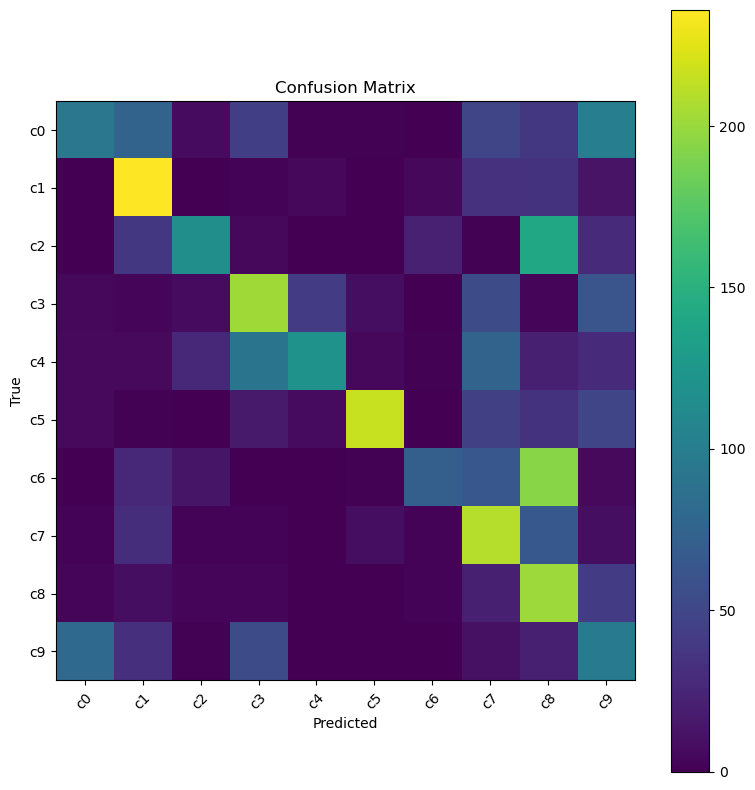

Confusion matrix shape: (10, 10)
Total test samples: 3525


In [27]:
# Confusion matrix helps visualize which classes are confused with each other
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45)
plt.yticks(range(NUM_CLASSES), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

print("Confusion matrix shape:", cm.shape)
print("Total test samples:", cm.sum())

# Q6 - Error Analysis
# 21 - Q6: Error Analysis Table

In [28]:
# Build a dataframe containing prediction results for deeper analysis
df_pred = pd.DataFrame({
    "path": paths_all,
    "true_id": y_true.astype(int),
    "pred_id": y_pred.astype(int),
})

# Add convenience columns
df_pred["is_correct"] = (df_pred["true_id"] == df_pred["pred_id"]).astype(int)
df_pred["true_class"] = df_pred["true_id"].map(id_to_class)
df_pred["pred_class"] = df_pred["pred_id"].map(id_to_class)

# Filter wrong predictions only
wrong = df_pred[df_pred["is_correct"] == 0].copy()

print("Q6 Total wrong predictions:", len(wrong))
df_pred.head()

Q6 Total wrong predictions: 1961


,path,true_id,pred_id,is_correct,true_class,pred_class
0,/home/aibox/statefarm_vit_project/data/extract...,0,0,1,c0,c0
1,/home/aibox/statefarm_vit_project/data/extract...,0,0,1,c0,c0
2,/home/aibox/statefarm_vit_project/data/extract...,0,0,1,c0,c0
3,/home/aibox/statefarm_vit_project/data/extract...,0,0,1,c0,c0
4,/home/aibox/statefarm_vit_project/data/extract...,0,0,1,c0,c0


# 22 - Q6: Top Confusion Pairs

In [29]:
# Find which (true -> predicted) mistakes happen most often
pair_counts = (
    wrong.groupby(["true_id", "pred_id"])
         .size()
         .reset_index(name="count")
         .sort_values("count", ascending=False)
)

# Map IDs back to class names for readability
pair_counts["true_class"] = pair_counts["true_id"].map(id_to_class)
pair_counts["pred_class"] = pair_counts["pred_id"].map(id_to_class)

print("Q6 Top confusion pairs")
pair_counts.head(15)

Q6 Top confusion pairs


,true_id,pred_id,count,true_class,pred_class
48,6,8,194,c6,c8
18,2,8,141,c2,c8
7,0,9,101,c0,c9
31,4,3,91,c4,c3
65,9,0,81,c9,c0
34,4,7,75,c4,c7
0,0,1,75,c0,c1
56,7,8,65,c7,c8
47,6,7,64,c6,c7
27,3,9,62,c3,c9


# 23 - Q6: Show Samples Helper

In [32]:
def show_samples(rows_df, title, n=12, cols=4):
    """
    Visualize a set of image paths with true/pred labels.
    Useful for qualitative error analysis.
    """
    n = min(n, len(rows_df))
    if n == 0:
        print("No samples to show.")
        return

    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(12, 3 * rows))

    for i in range(n):
        r = rows_df.iloc[i]
        img = Image.open(r["path"]).convert("RGB")
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.set_title(f"T:{r['true_class']} P:{r['pred_class']}", fontsize=9)
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# 24 - Q6: Show Most Frequent Confusion Examples

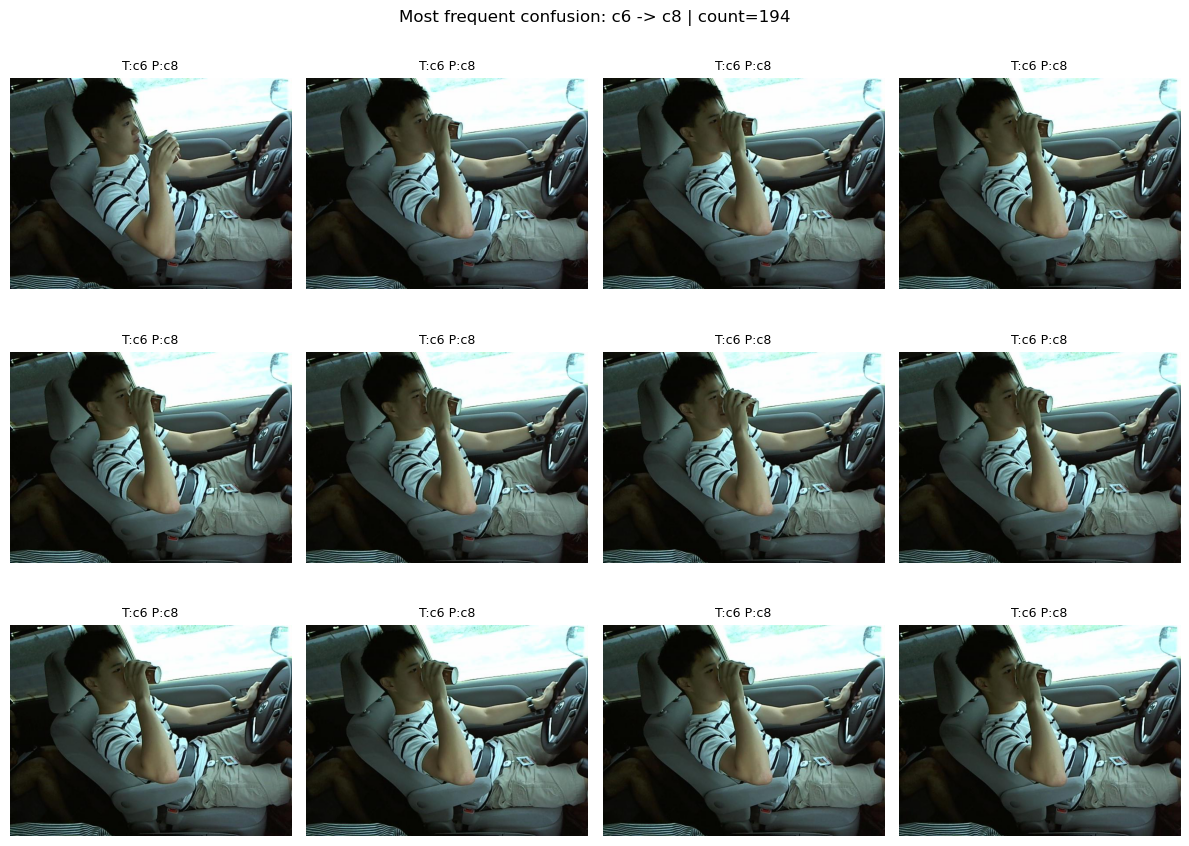

In [33]:
# Display examples from the most frequent confusion pair
if len(pair_counts) > 0:
    top_pair = pair_counts.iloc[0]
    t_id, p_id = int(top_pair["true_id"]), int(top_pair["pred_id"])

    subset = wrong[(wrong["true_id"] == t_id) & (wrong["pred_id"] == p_id)].head(12).reset_index(drop=True)
    title = f"Most frequent confusion: {id_to_class[t_id]} -> {id_to_class[p_id]} | count={int(top_pair['count'])}"
    show_samples(subset, title, n=12, cols=4)
else:
    print("No confusion pairs found (perfect classification or empty wrong set).")

# 25 - Q6: Show Random Mistakes

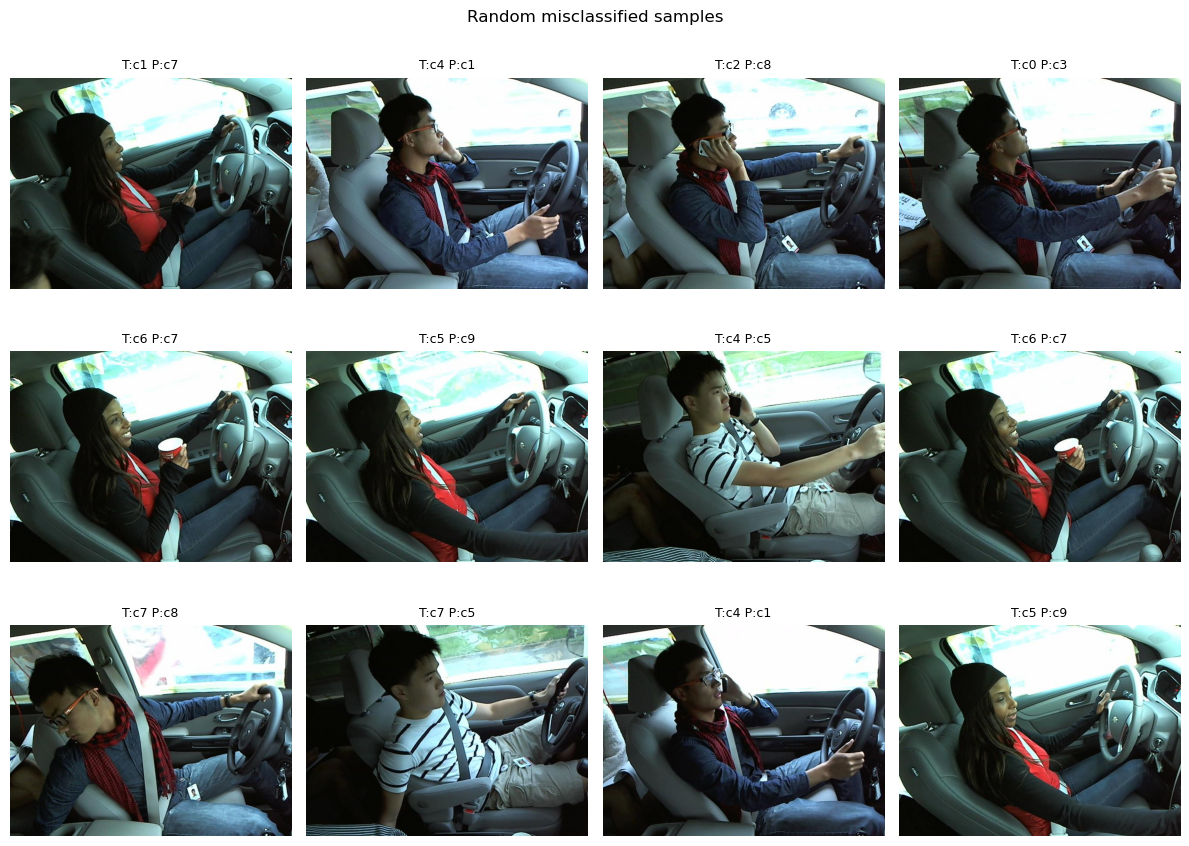

In [34]:
# Show random misclassified samples for broader insight
if len(wrong) > 0:
    sample_wrong = wrong.sample(n=min(12, len(wrong)), random_state=SEED).reset_index(drop=True)
    show_samples(sample_wrong, "Random misclassified samples", n=12, cols=4)
else:
    print("No wrong predictions to display.")

# Final - Important Results (Questions 1 to 6)
# 26 - Important Results Summary (Save for Report)

In [35]:
top_confusion = None
if pair_counts is not None and len(pair_counts) > 0:
    r0 = pair_counts.iloc[0]
    top_confusion = {
        "true_class": r0["true_class"],
        "pred_class": r0["pred_class"],
        "count": int(r0["count"])
    }

summary = {
    "selected_optimizer": selected_name if "selected_name" in globals() else None,
    "best_val_acc": float(selected_val) if "selected_val" in globals() else None,
    "test_accuracy": float(acc),
    "test_macro_f1": float(f1m),
    "top_confusion_pair": top_confusion,
    "num_test_samples": int(len(y_true)),
    "num_wrong_predictions": int(len(wrong)),
}

print("===== IMPORTANT RESULTS (Q1-Q6) =====")
for k, v in summary.items():
    print(f"{k}: {v}")

out_path = os.path.join(WORKDIR, "important_results_q1_q6.json")
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved:", out_path)

===== IMPORTANT RESULTS (Q1-Q6) =====
selected_optimizer: AdamW
best_val_acc: 0.45730437369830407
test_accuracy: 0.44368794326241134
test_macro_f1: 0.440102271840615
top_confusion_pair: {'true_class': 'c6', 'pred_class': 'c8', 'count': 194}
num_test_samples: 3525
num_wrong_predictions: 1961

Saved: /home/aibox/statefarm_vit_project/important_results_q1_q6.json


# 27 - Q8: Build Stable Benchmark Loader (Fixed Batch Size)

In [38]:
bench_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    drop_last=True,            # IMPORTANT: ensures fixed batch size for all iterations
    worker_init_fn=worker_init_fn
)

print("Q8 bench_loader ready")
print("bench batches:", len(bench_loader), "| batch_size:", BATCH_SIZE, "| drop_last:", True)

Q8 bench_loader ready
bench batches: 55 | batch_size: 64 | drop_last: True


# 28 - Q8: Compile + Benchmark Base vs Compiled (Comparable Output)

In [ ]:
from contextlib import nullcontext

def benchmark_inference(model, loader, warmup_batches=10, test_batches=60):
    """
    Throughput benchmark in samples/sec using fixed-shape batches.
    Uses inference_mode + AUTOCAST for stable and realistic inference timing.
    """
    model.eval()

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    # Warmup
    with torch.inference_mode():
        for i, (x, _, _) in enumerate(loader):
            if i >= warmup_batches:
                break
            x = x.to(DEVICE, non_blocking=True)
            if DEVICE == "cuda":
                x = x.to(memory_format=torch.channels_last)
            with AUTOCAST:
                _ = model(x)

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    n = 0
    t0 = time.time()

    with torch.inference_mode():
        for i, (x, _, _) in enumerate(loader):
            if i >= test_batches:
                break
            x = x.to(DEVICE, non_blocking=True)
            if DEVICE == "cuda":
                x = x.to(memory_format=torch.channels_last)
            with AUTOCAST:
                _ = model(x)
            n += x.size(0)

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    dt = time.time() - t0
    sps = (n / dt) if dt > 0 else None
    return n, dt, sps

# Base model benchmark
model_base = model_final
model_base.eval()

if DEVICE == "cuda":
    model_base = model_base.to(memory_format=torch.channels_last)

base_n, base_dt, base_sps = benchmark_inference(model_base, bench_loader)
print("\nQ8 Base benchmark (fixed batches)")
print("Samples:", base_n, "| Seconds:", base_dt, "| Samples/sec:", base_sps)

# Compiled model benchmark
compiled_model = None
compile_ok = False
comp_n = comp_dt = comp_sps = None

if DEVICE == "cuda" and hasattr(torch, "compile"):
    try:
        # Disable cudagraphs to avoid "live storage ptrs" issues on some setups
        import torch._inductor.config as inductor_config
        inductor_config.triton.cudagraphs = False

        # Use safer compile mode
        compiled_model = torch.compile(model_base, mode="reduce-overhead")
        compile_ok = True
        print("\nQ8 torch.compile enabled (reduce-overhead, cudagraphs OFF)")

        comp_n, comp_dt, comp_sps = benchmark_inference(compiled_model, bench_loader)
        print("\nQ8 Compiled benchmark (fixed batches)")
        print("Samples:", comp_n, "| Seconds:", comp_dt, "| Samples/sec:", comp_sps)

        if base_sps and comp_sps:
            print("\nQ8 Speedup factor:", comp_sps / base_sps)

    except Exception as e:
        print("\nQ8 compiled benchmark failed:", str(e))
        print("Q8 NOTE: Base benchmark is valid; compiled speedup not available on this environment.")
else:
    print("\nQ8 compile skipped (needs CUDA + torch.compile).")


Q8 Base benchmark (fixed batches)
Samples: 3520 | Seconds: 8.104297161102295 | Samples/sec: 434.3374792443114

Q8 torch.compile enabled (reduce-overhead, cudagraphs OFF)

Q8 Compiled benchmark (fixed batches)
Samples: 3520 | Seconds: 8.107030868530273 | Samples/sec: 434.19101975593463

Q8 Speedup factor: 0.9996627979500374


# 29 - Q8 Base vs Compiled Model Output Consistency Check

In [41]:
from contextlib import nullcontext
import numpy as np
import torch

def verify_compiled_output(model_a, model_b, loader, num_batches=5, atol=1e-3, rtol=1e-3):
    # Computes numerical differences between logits and checks top-1 agreement across a few batches.
    model_a.eval()
    model_b.eval()

    # Autocast is disabled to compare outputs in float32 for better numerical stability.
    if DEVICE == "cuda":
        cmp_ctx = torch.cuda.amp.autocast(enabled=False)
    else:
        cmp_ctx = nullcontext()

    max_abs_diffs = []
    mean_abs_diffs = []
    total = 0
    same_top1 = 0

    with torch.inference_mode(), cmp_ctx:
        for i, (x, _, _) in enumerate(loader):
            if i >= num_batches:
                break

            x = x.to(DEVICE, non_blocking=True)

            # channels_last can improve memory access patterns on CUDA.
            if DEVICE == "cuda":
                x = x.to(memory_format=torch.channels_last)

            logits_a = model_a(x).float()
            logits_b = model_b(x).float()

            diff = (logits_a - logits_b).abs()
            max_abs_diffs.append(diff.max().item())
            mean_abs_diffs.append(diff.mean().item())

            pred_a = logits_a.argmax(dim=1)
            pred_b = logits_b.argmax(dim=1)
            same_top1 += (pred_a == pred_b).sum().item()
            total += x.size(0)

    max_abs = float(np.max(max_abs_diffs)) if max_abs_diffs else None
    mean_abs = float(np.mean(mean_abs_diffs)) if mean_abs_diffs else None
    top1_match = (same_top1 / total) if total > 0 else None

    print("\nQ8 Output Consistency Check")
    print("Batches checked:", min(num_batches, len(loader)))
    print("Max abs diff (logits):", max_abs)
    print("Mean abs diff (logits):", mean_abs)
    print("Top-1 prediction match:", top1_match)

    # The thresholds provide a practical tolerance for minor numerical differences.
    if top1_match is not None and top1_match >= 0.99:
        print("Status: PASS (top-1 agreement >= 99%)")
    else:
        print("Status: WARNING (top-1 agreement < 99%)")


if compile_ok and compiled_model is not None:
    verify_compiled_output(model_base, compiled_model, bench_loader, num_batches=5, atol=1e-3, rtol=1e-3)
else:
    print("\nQ8 output consistency check skipped (compiled model is not available).")

/tmp/ipykernel_74/3435578439.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  cmp_ctx = torch.cuda.amp.autocast(enabled=False)
/opt/conda/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:236: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(



Q8 Output Consistency Check
Batches checked: 5
Max abs diff (logits): 6.556510925292969e-06
Mean abs diff (logits): 3.792478082687012e-07
Top-1 prediction match: 1.0
Status: PASS (top-1 agreement >= 99%)
